# ABBOZZO TESI

### Librerie

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm, shapiro, normaltest, probplot, kruskal
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, normal_ad
from pandas.plotting import lag_plot
from statsmodels.tsa.arima_process import arma_generate_sample


## Dataset: Spesa di viaggiatori stranieri (in milioni) in Calabria

In [8]:
df = pd.read_csv("Viaggiatori stranieri - Spesa in Calabria.csv", encoding="latin1", sep=";")
df = df.iloc[:, 2]   

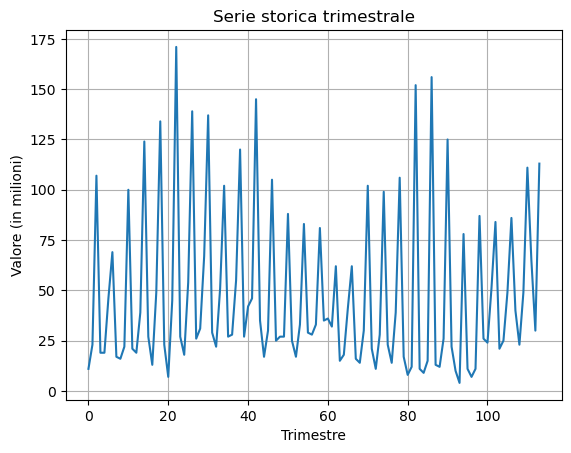

In [11]:
plt.plot(df)
plt.title("Serie storica trimestrale")
plt.xlabel("Trimestre")
plt.ylabel("Valore (in milioni)")
plt.grid(True)
plt.show()

### Statistiche descrittive

In [10]:
x = df.values  

print("N osservazioni:", len(x))
print("Media:", np.mean(x))
print("Deviazione standard:", np.std(x, ddof=1))  # ddof=1 → stima campionaria
print("Varianza:", np.var(x, ddof=1))
print("Minimo:", np.min(x))
print("Massimo:", np.max(x))
print("Mediana:", np.median(x))
print("Quantili 25%-75%:", np.percentile(x, [25, 75]))
print("Asimmetria (skewness):", pd.Series(x).skew())
print("Curtosi (kurtosis):", pd.Series(x).kurtosis())

N osservazioni: 114
Media: 47.228070175438596
Deviazione standard: 40.09458619639962
Varianza: 1607.5758422605186
Minimo: 4
Massimo: 171
Mediana: 29.0
Quantili 25%-75%: [19.   64.25]
Asimmetria (skewness): 1.3011915626845938
Curtosi (kurtosis): 0.6991388119178685


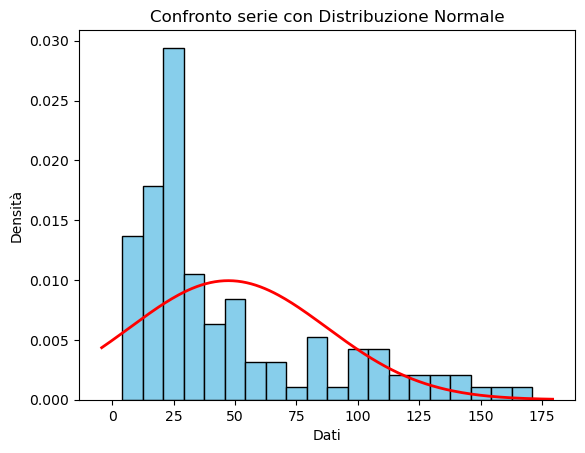

In [ ]:
plt.hist(df, bins=20, density=True, color="skyblue", edgecolor="black")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, np.mean(df), np.std(df, ddof=1))  
plt.plot(x, p, "r", linewidth=2)
plt.title("Confronto serie con Distribuzione Normale")
plt.xlabel("Dati")
plt.ylabel("Densità")

plt.show()

## Verifica della normalità

Shapiro-Wilk Test:
Statistic: 0.8233, p-value: 0.0000

D’Agostino-Pearson Test:
Statistic: 24.9559, p-value: 0.0000


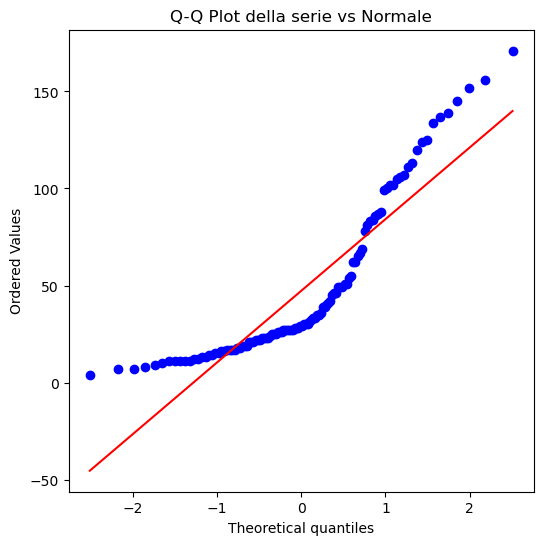

In [ ]:
# Test di Shapiro-Wilk
stat_shapiro, p_shapiro = shapiro(df)
print("Shapiro-Wilk Test:")
print(f"Statistic: {stat_shapiro:.4f}, p-value: {p_shapiro:.4f}")

# Test di D’Agostino-Pearson (K^2 test) 
stat_dag, p_dag = normaltest(df)
print("\nD’Agostino-Pearson Test:")
print(f"Statistic: {stat_dag:.4f}, p-value: {p_dag:.4f}")

# Q-Q plot
plt.figure(figsize=(6,6))
probplot(df, dist="norm", plot=plt)
plt.title("Q-Q Plot della serie vs Normale")
plt.show()


### Funzione di autocorrelazione totale e parziale

<Figure size 1000x400 with 0 Axes>

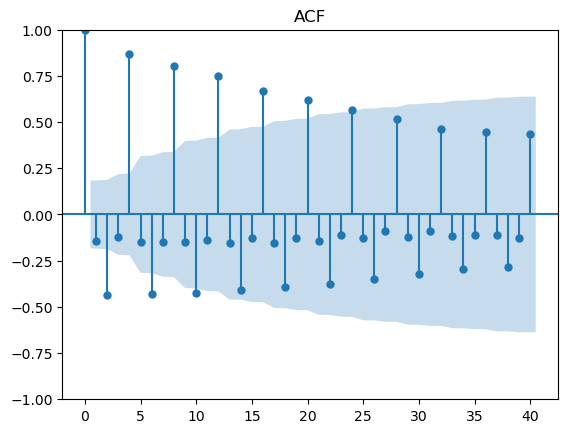

<Figure size 1000x400 with 0 Axes>

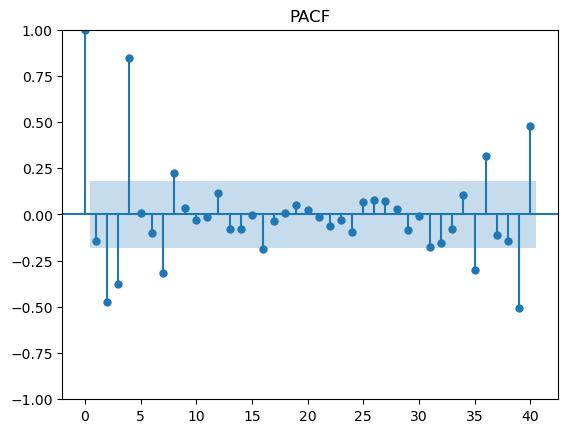

In [29]:
lags = 40

acf_vals = acf(df, nlags=lags, fft=True)
pacf_vals = pacf(df, nlags=lags, method="yw")  # oppure method="ols"

plt.figure(figsize=(10,4))
plot_acf(df, lags=lags)
plt.title("ACF")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(df, lags=lags, method="yw")
plt.title("PACF")
plt.show()

In [25]:
result = adfuller(df, maxlag=None, regression='c', autolag='AIC')

adf_stat, pvalue, usedlag, nobs, crit_vals, icbest = result
print(f"ADF statistic   : {adf_stat:.4f}")
print(f"p-value         : {pvalue:.4f}")
print(f"Lags utilizzati : {usedlag}")
print(f"N obs           : {int(nobs)}")
print("Valori critici  :", {k: round(v,4) for k, v in crit_vals.items()})
print(f"IC (migliore)   : {icbest:.4f}")

ADF statistic   : -1.3751
p-value         : 0.5942
Lags utilizzati : 4
N obs           : 109
Valori critici  : {'1%': -3.4918, '5%': -2.8884, '10%': -2.5811}
IC (migliore)   : 852.4271



La serie sembra NON stazionaria (p > 0.05). Provo una differenza di primo ordine...


<Figure size 1000x400 with 0 Axes>

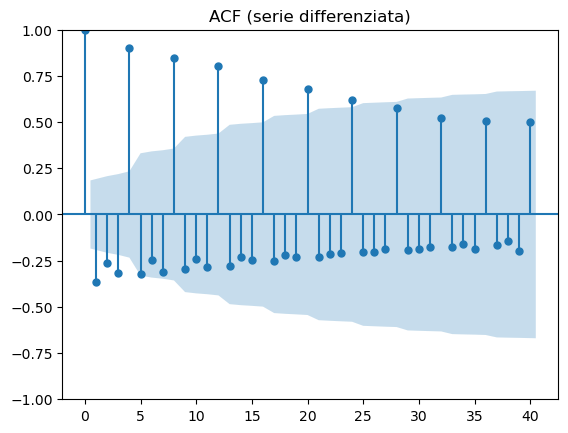

<Figure size 1000x400 with 0 Axes>

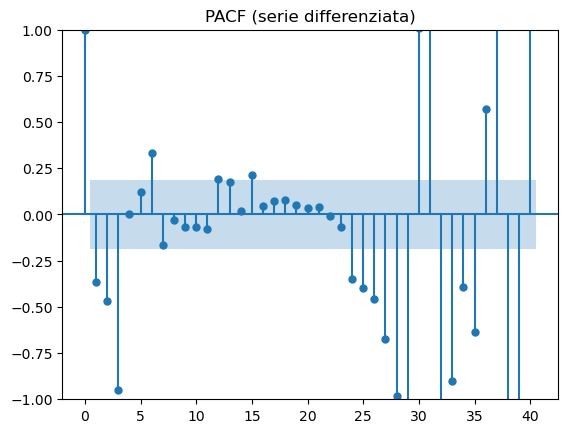

ADF statistic   : -8.3814
p-value         : 0.0000
Valori critici  : {'1%': -3.4918, '5%': -2.8884, '10%': -2.5811}


In [27]:
# (Opzionale) Se non stazionaria, differenzia e ripeti
if pvalue > 0.05:
    print("\nLa serie sembra NON stazionaria (p > 0.05). Provo una differenza di primo ordine...")
    Y_diff = df.diff().dropna()

    # ACF/PACF differenziata
    plt.figure(figsize=(10,4))
    plot_acf(Y_diff, lags=lags)
    plt.title("ACF (serie differenziata)")
    plt.show()

    plt.figure(figsize=(10,4))
    plot_pacf(Y_diff, lags=lags, method="yw")
    plt.title("PACF (serie differenziata)")
    plt.show()

    res_diff = adfuller(Y_diff, regression='c', autolag='AIC')
    print(f"ADF statistic   : {res_diff[0]:.4f}")
    print(f"p-value         : {res_diff[1]:.4f}")
    print("Valori critici  :", {k: round(v,4) for k, v in res_diff[4].items()})

### Test di Ljung-Box e Box-Pierce

In [36]:
results = acorr_ljungbox(df, lags=[36], return_df=True, boxpierce=True)

print(results)

       lb_stat      lb_pvalue     bp_stat      bp_pvalue
36  737.054006  1.122321e-131  618.863451  2.682239e-107


### Lag Plot

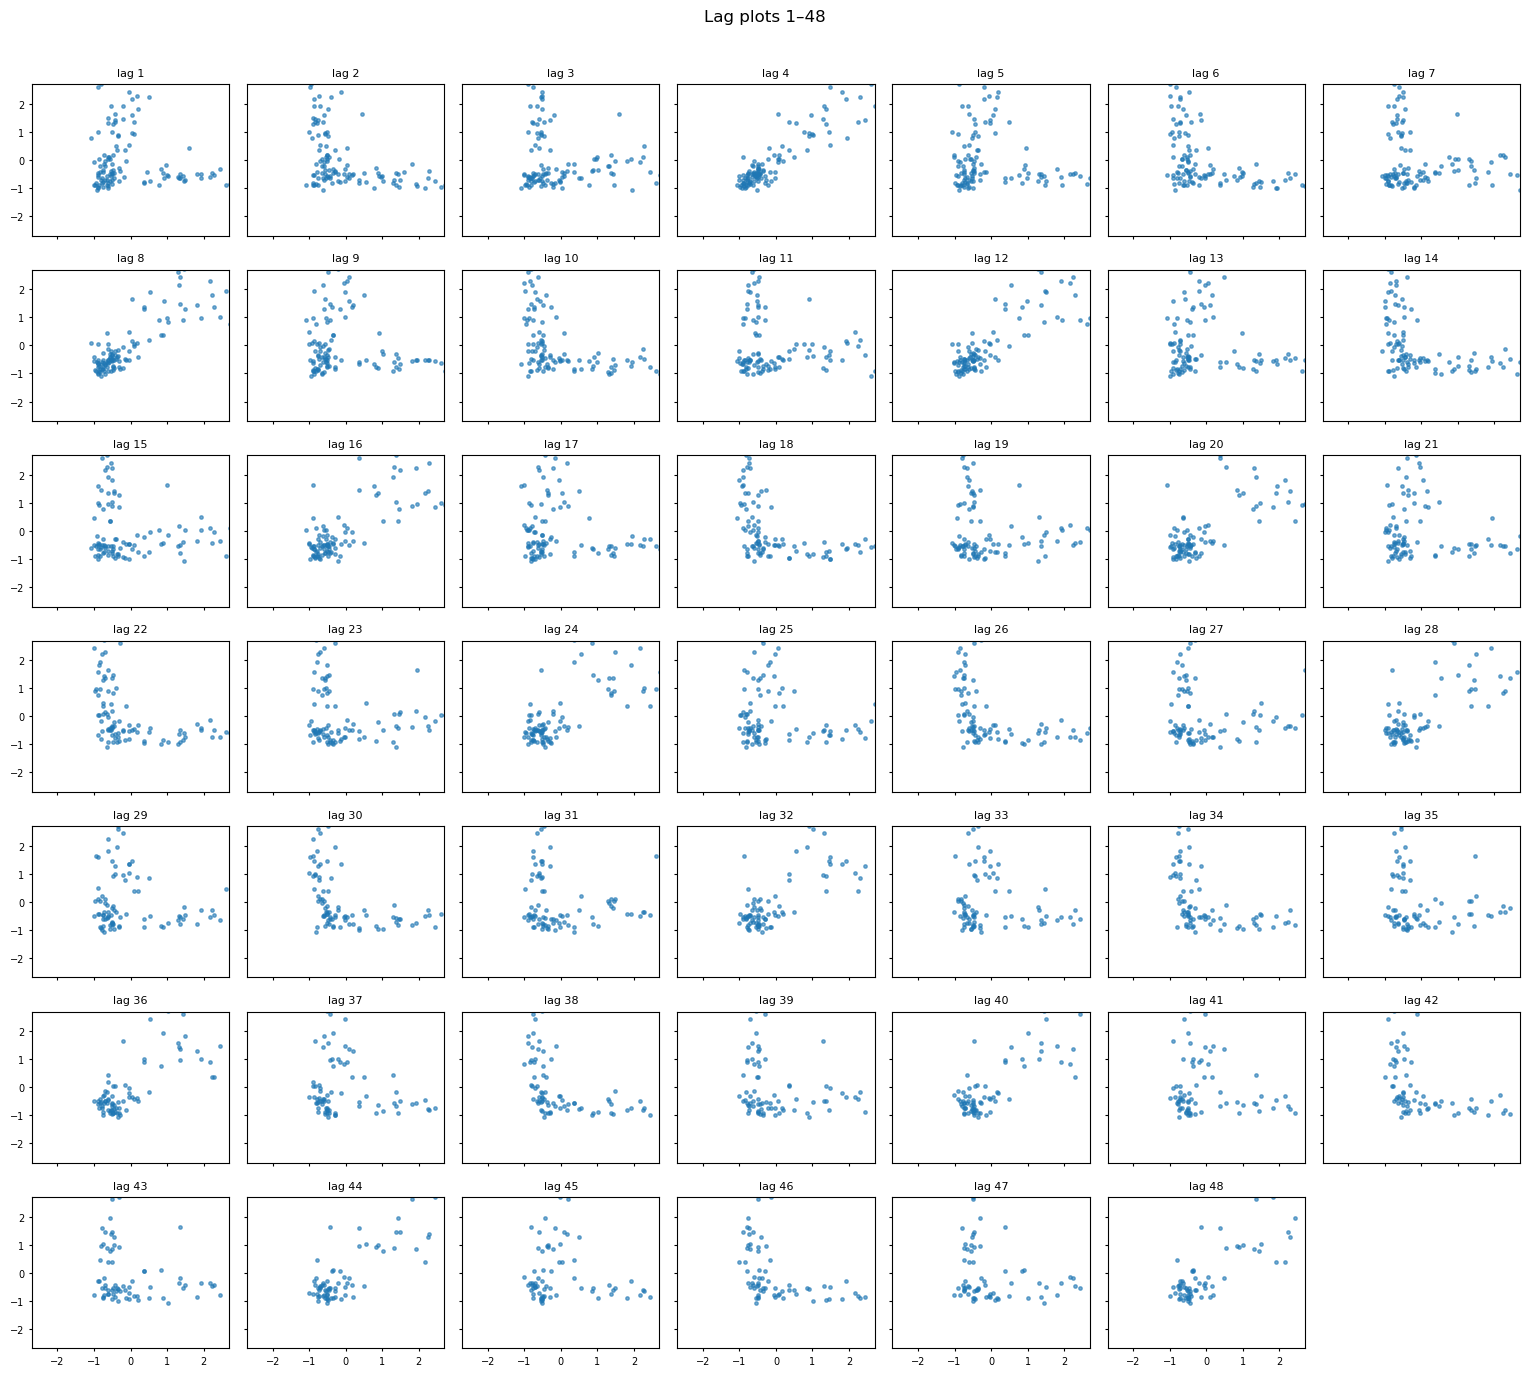

In [47]:
def lagplot_grid(y, max_lag=48, n_cols=7, standardize=True, s=6, alpha=0.6):
    """
    Crea una griglia di lag plot (scatter Y_t vs Y_{t-k}) per k=1..max_lag.

    y            : array-like o pd.Series
    max_lag      : ultimo lag da plottare
    n_cols       : numero di colonne nella griglia
    standardize  : se True usa z-score (stessa scala per tutti i pannelli)
    s, alpha     : stile dei punti
    """
    y = pd.Series(y).dropna().astype(float)
    if standardize:
        y = (y - y.mean()) / y.std(ddof=1)

    n_rows = int(np.ceil(max_lag / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 2.2, n_rows * 2.0),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    # limiti comuni (robusti agli outlier)
    lim = np.nanpercentile(np.abs(y), 99)
    lim = max(lim, 1.0)  # evita range troppo piccolo

    for k in range(1, max_lag + 1):
        ax = axes[k - 1]
        x = y.shift(k).dropna()
        ax.scatter(x, y.iloc[k:], s=s, alpha=alpha)
        ax.set_title(f"lag {k}", fontsize=8)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.tick_params(labelsize=7, length=2)

    # nascondi assi in eccesso
    for j in range(max_lag, n_rows * n_cols):
        axes[j].axis("off")

    fig.suptitle(f"Lag plots 1–{max_lag}", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Esempio d’uso sulla tua serie (quarta colonna del DataFrame df)
lagplot_grid(df, max_lag=48, n_cols=7)

### Test di Kruskal-Wallis e il test combinato

In [71]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

def _get_quarter_index(y, freq=4):
    """Restituisce i numeri di trimestre (1..freq). Funziona con DatetimeIndex/PeriodIndex o con semplice indice intero."""
    if isinstance(y.index, (pd.DatetimeIndex, pd.PeriodIndex)):
        try:
            q = pd.Series(getattr(y.index, "quarter"), index=y.index)
        except Exception:
            # PeriodIndex senza .quarter — converti a datetime
            q = pd.Series(y.index.to_timestamp().quarter, index=y.index)
        return q
    # fallback: sequenziale
    n = len(y)
    return pd.Series((np.arange(n) % freq) + 1, index=y.index)

def is_seasonal(y, freq=4, test="combined", alpha=0.05, max_seasonal_harmonics=3):
    """
    y: pd.Series numerica (eventuali NaN verranno rimossi in modo sincrono)
    freq: 4 per serie trimestrali
    test: 'kw' | 'reg' | 'combined'
    alpha: livello di significatività
    max_seasonal_harmonics: quante multipli stagionali considerare per Ljung-Box (es. 4,8,12)
    """
    y = pd.Series(y).astype(float).copy()
    mask = ~y.isna()
    y = y[mask]

    # trimestri 1..freq
    q = _get_quarter_index(y, freq=freq).loc[y.index]
    results = {}

    # ---------- (1) Kruskal–Wallis su gruppi stagionali ----------
    try:
        groups = [y[q == s] for s in range(1, freq+1)]
        stat_kw, p_kw = kruskal(*groups)
        results["kw_stat"] = float(stat_kw)
        results["kw_pvalue"] = float(p_kw)
    except Exception:
        results["kw_stat"] = np.nan
        results["kw_pvalue"] = np.nan

    # ---------- (2) Regressione con dummies stagionali + F-test ----------
    try:
        # Intercetta + dummies (drop 1 categoria per evitare collinearità)
        X = pd.get_dummies(q.astype("category"), prefix="Q", drop_first=True)
        X = sm.add_constant(X)
        model = sm.OLS(y.values, X.values).fit()
        # Test congiunto: tutti i coefficienti delle dummies = 0
        # (tutte le colonne eccetto la costante)
        k = X.shape[1]
        R = np.c_[np.zeros((k-1,1)), np.eye(k-1)]  # esclude la costante
        ftest = model.f_test(R)
        results["reg_F"] = float(ftest.fvalue)
        results["reg_pvalue"] = float(ftest.pvalue)
    except Exception:
        results["reg_F"] = np.nan
        results["reg_pvalue"] = np.nan

    # ---------- (3) Ljung–Box su lag stagionali ----------
    try:
        lags = [freq * i for i in range(1, max_seasonal_harmonics+1)]
        lags = [L for L in lags if L < len(y)]  # evita lag > N
        if lags:
            lb = acorr_ljungbox(y, lags=lags, return_df=True)
            results["lb_lags"] = lags
            results["lb_stat"] = lb["lb_stat"].tolist()
            results["lb_pvalue"] = lb["lb_pvalue"].tolist()
            results["lb_any_sig"] = bool((lb["lb_pvalue"] < alpha).any())
        else:
            results["lb_lags"] = []
            results["lb_stat"] = []
            results["lb_pvalue"] = []
            results["lb_any_sig"] = False
    except Exception:
        results["lb_lags"] = []
        results["lb_stat"] = []
        results["lb_pvalue"] = []
        results["lb_any_sig"] = False

    # ---------- decisione ----------
    if test == "kw":
        decision = (results.get("kw_pvalue", 1.0) < alpha)
    elif test == "reg":
        decision = (results.get("reg_pvalue", 1.0) < alpha)
    else:  # combined
        decision = (
            (results.get("kw_pvalue", 1.0) < alpha) or
            (results.get("reg_pvalue", 1.0) < alpha) or
            results.get("lb_any_sig", False)
        )

    results["seasonal"] = bool(decision)
    results["alpha"] = alpha
    results["test"] = test
    results["freq"] = freq
    return results


In [73]:
out_kw = is_seasonal(df, freq=4, test="kw")
out_reg = is_seasonal(df, freq=4, test="reg")
out_comb = is_seasonal(df, freq=4, test="combined")

print("KW:", out_kw)
print("REG:", out_reg)
print("COMBINED:", out_comb)


KW: {'kw_stat': 73.9236979506477, 'kw_pvalue': 6.16261362471658e-16, 'reg_F': nan, 'reg_pvalue': nan, 'lb_lags': [4, 8, 12], 'lb_stat': [117.23111537678709, 225.50965367312477, 326.8251020175698], 'lb_pvalue': [2.0842334098585273e-24, 2.6366981293997717e-44, 1.0751944889934908e-62], 'lb_any_sig': True, 'seasonal': True, 'alpha': 0.05, 'test': 'kw', 'freq': 4}
REG: {'kw_stat': 73.9236979506477, 'kw_pvalue': 6.16261362471658e-16, 'reg_F': nan, 'reg_pvalue': nan, 'lb_lags': [4, 8, 12], 'lb_stat': [117.23111537678709, 225.50965367312477, 326.8251020175698], 'lb_pvalue': [2.0842334098585273e-24, 2.6366981293997717e-44, 1.0751944889934908e-62], 'lb_any_sig': True, 'seasonal': False, 'alpha': 0.05, 'test': 'reg', 'freq': 4}
COMBINED: {'kw_stat': 73.9236979506477, 'kw_pvalue': 6.16261362471658e-16, 'reg_F': nan, 'reg_pvalue': nan, 'lb_lags': [4, 8, 12], 'lb_stat': [117.23111537678709, 225.50965367312477, 326.8251020175698], 'lb_pvalue': [2.0842334098585273e-24, 2.6366981293997717e-44, 1.075194

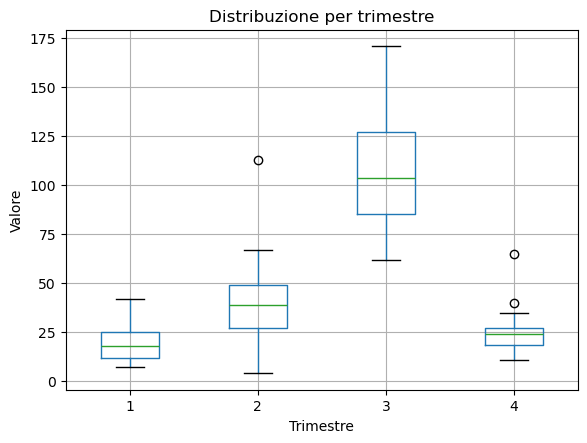

In [75]:
tmp = pd.DataFrame({"Y": df})
tmp["quarter"] = ((np.arange(len(tmp)) % 4) + 1).astype(int)
tmp.boxplot(column="Y", by="quarter")
plt.title("Distribuzione per trimestre")
plt.suptitle("")
plt.xlabel("Trimestre")
plt.ylabel("Valore")
plt.show()


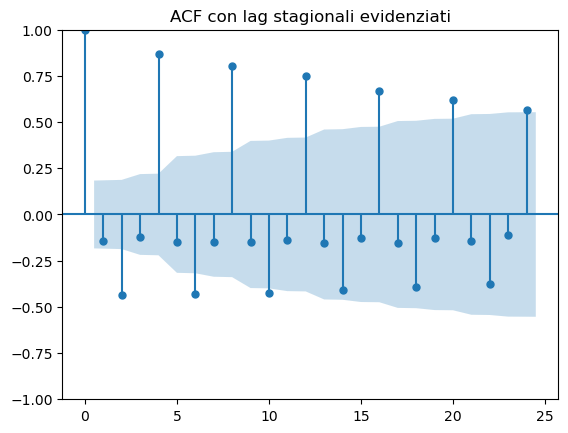

In [77]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df, lags=24)
plt.title("ACF con lag stagionali evidenziati")
plt.show()


### Grafici della stagionalità

In [91]:
def seasonal_plot(Y, freq=4, start_year=1997, ylabel="Data", title="Seasonal plot"):
    """
    Y: pd.Series con dati trimestrali
    freq: frequenza stagionale (4 = trimestri, 12 = mensile)
    start_year: anno di inizio (se Y non ha DateTimeIndex)
    """
    Y = pd.Series(Y).reset_index(drop=True)
    n = len(Y)
    n_years = n // freq
    
    # crea matrice anni x stagioni
    data = Y.values.reshape(n_years, freq)
    years = np.arange(start_year, start_year+n_years)

    plt.figure(figsize=(8,5))
    for i, row in enumerate(data):
        plt.plot(range(1, freq+1), row, marker="o", label=str(years[i]))
    plt.xticks(range(1, freq+1))
    plt.xlabel("Quarter")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.2,1.05))
    plt.show()


In [ ]:
def polar_seasonal_plot(Y, freq=4, start_year=1997, ylabel="Data", title="Polar seasonal plot"):
    Y = pd.Series(Y).reset_index(drop=True)
    n = len(Y)
    n_years = n // freq
    data = Y.values.reshape(n_years, freq)
    years = np.arange(start_year, start_year+n_years)

    angles = np.linspace(0, 2*np.pi, freq, endpoint=False)

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    for i, row in enumerate(data):
        ax.plot(angles, row, marker="o", label=str(years[i]))
    ax.set_xticks(angles)
    ax.set_xticklabels([f"Q{q}" for q in range(1,freq+1)])
    plt.title(title)
    plt.legend(loc="upper right", fontsize=7, bbox_to_anchor=(1.2,1.05))
    plt.show()

In [80]:
def seasonal_subseries_plot(Y, freq=4, ylabel="Data", title="Seasonal subseries plot"):
    Y = pd.Series(Y).reset_index(drop=True)
    n = len(Y)
    quarters = (np.arange(n) % freq) + 1
    df = pd.DataFrame({"value": Y, "quarter": quarters})

    plt.figure(figsize=(8,5))
    for q in range(1, freq+1):
        subset = df[df["quarter"]==q]["value"].reset_index(drop=True)
        plt.plot(subset.index, subset.values, marker="o", label=f"Q{q}")
    plt.xlabel("Anno (indice)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

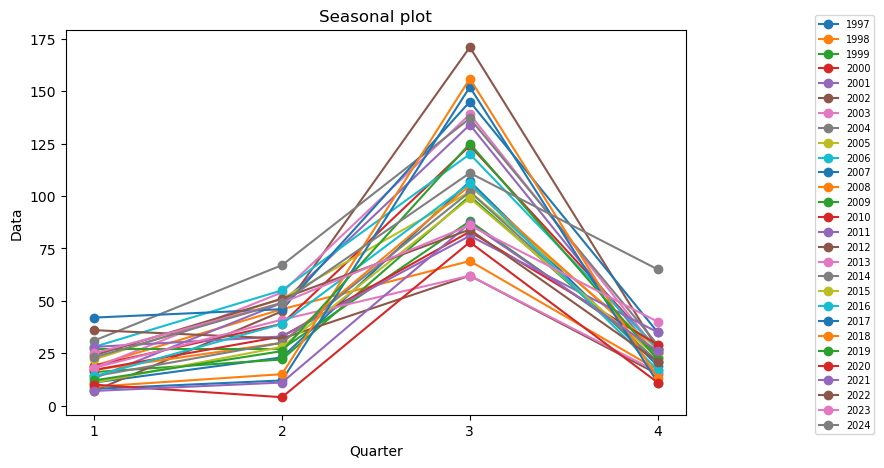

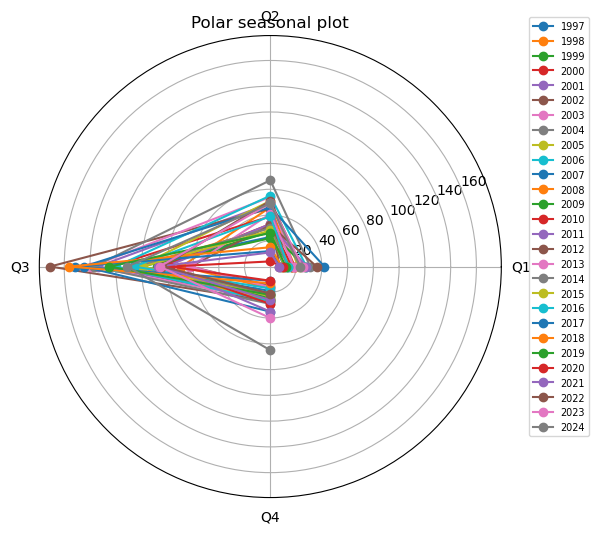

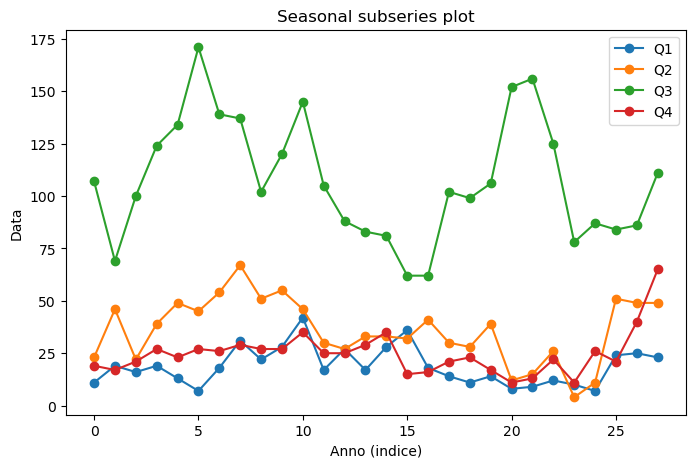

In [92]:
Y = df.astype(float).dropna()
n = len(Y)
n_years = n // 4   # anni interi
Y = Y.iloc[:n_years*4]  # tieni solo multiplo di 4

seasonal_plot(Y, freq=4, start_year=1997)
polar_seasonal_plot(Y, freq=4, start_year=1997)
seasonal_subseries_plot(Y, freq=4)

# Modello SARIMA

### Ricerca del miglior SARIMA con AIC e BIC

In [ ]:
def best_sarima(y, p_range, d_range, q_range, P_range, D_range, Q_range, s=4):
    """
    Cerca il modello SARIMA migliore (per AIC) in una griglia di parametri.

    y : array-like o pd.Series
        Serie storica
    p_range, d_range, q_range : range
        Range per p,d,q
    P_range, D_range, Q_range : range
        Range per P,D,Q
    s : int
        Periodo stagionale (4 = trimestrale)

    Returns:
    --------
    best_result : SARIMAXResults
        Oggetto SARIMA stimato con AIC minimo
    best_params : tuple
        Parametri (order, seasonal_order)
    """
    best_aic = np.inf
    best_result = None
    best_params = None

    for order in itertools.product(p_range, d_range, q_range):
        for seasonal in itertools.product(P_range, D_range, Q_range, [s]):
            try:
                model = sm.tsa.SARIMAX(y, order=order, seasonal_order=seasonal,
                                       enforce_stationarity=False,
                                       enforce_invertibility=False)
                res = model.fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_result = res
                    best_params = (order, seasonal)
            except Exception as e:
                continue

    print("Miglior modello SARIMA trovato:")
    print(f"order={best_params[0]}, seasonal_order={best_params[1]}, AIC={best_aic:.2f}, BIC={best_result.bic:.2f}")
    return best_result, best_params


In [ ]:
best_model, best_params = best_sarima(
    df,
    p_range=range(0,3),
    d_range=range(0,2),
    q_range=range(0,3),
    P_range=range(0,2),
    D_range=range(0,2),
    Q_range=range(0,2),
    s=4  # stagionalità trimestrale
)


/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmo

Miglior modello SARIMA trovato:
order=(0, 1, 2), seasonal_order=(0, 1, 1, 4), AIC=871.89, BIC=882.39


In [ ]:
print(best_model.summary())

                                      SARIMAX Results                                      
Dep. Variable:            SPESA IN MILIONI DI EURO   No. Observations:                  114
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 4)   Log Likelihood                -431.943
Date:                             Thu, 02 Oct 2025   AIC                            871.886
Time:                                     17:59:39   BIC                            882.386
Sample:                                          0   HQIC                           876.138
                                             - 114                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7999      0.121     -6.607      0.000      -1.037      -0.563
ma.L2         -0.1370      

### Stime col SARIMA

In [110]:
# Y: la tua serie trimestrale (pandas Series con 114 osservazioni)
model = sm.tsa.SARIMAX(
    df,
    order=(0,1,2),                 # (p,d,q)
    seasonal_order=(0,1,1,4),      # (P,D,Q,s)
    enforce_stationarity=False,
    enforce_invertibility=False
)
res = model.fit(disp=False)

In [111]:
print(res.summary())

                                      SARIMAX Results                                      
Dep. Variable:            SPESA IN MILIONI DI EURO   No. Observations:                  114
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 4)   Log Likelihood                -431.943
Date:                             Thu, 02 Oct 2025   AIC                            871.886
Time:                                     18:05:51   BIC                            882.386
Sample:                                          0   HQIC                           876.138
                                             - 114                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7999      0.121     -6.607      0.000      -1.037      -0.563
ma.L2         -0.1370      

In [112]:
params = res.params
stderr = res.bse
zvals = params / stderr
pvals = res.pvalues

for name, coef, se, z, p in zip(res.param_names, params, stderr, zvals, pvals):
    print(f"{name:15s} coef={coef:8.4f}, se={se:8.4f}, z={z:8.3f}, p={p:8.4f}")

ma.L1           coef= -0.7999, se=  0.1211, z=  -6.607, p=  0.0000
ma.L2           coef= -0.1370, se=  0.1231, z=  -1.113, p=  0.2658
ma.S.L4         coef= -0.0599, se=  0.1040, z=  -0.576, p=  0.5646
sigma2          coef=277.0970, se= 28.7286, z=   9.645, p=  0.0000


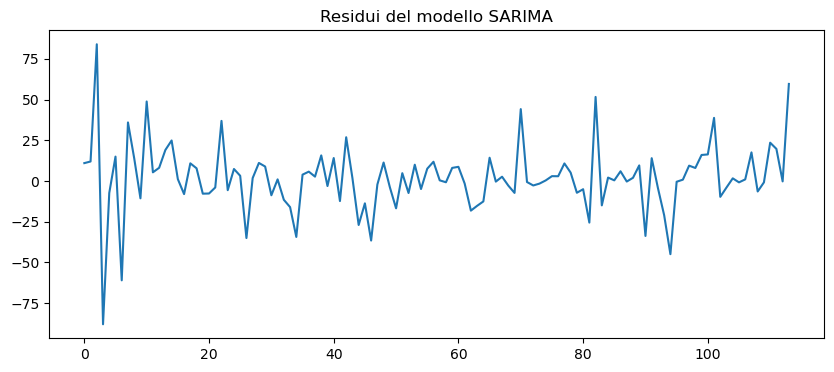

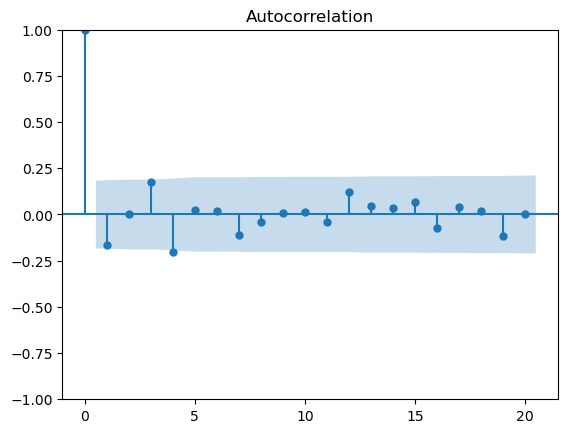


Ljung–Box test:
      lb_stat  lb_pvalue
10  13.794831   0.182557
20  19.827604   0.468759

Normalità (Anderson–Darling): stat=3.545, p-value=0.000
Test ARCH: stat=13.702, p-value=0.187


In [113]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, normal_ad

resid = res.resid.dropna()

# Plot residui
plt.figure(figsize=(10,4))
plt.plot(resid)
plt.title("Residui del modello SARIMA")
plt.show()

# ACF residui
plot_acf(resid, lags=20)
plt.show()

# Ljung–Box test
lb = acorr_ljungbox(resid, lags=[10,20], return_df=True)
print("\nLjung–Box test:")
print(lb)

# Test di normalità (Anderson–Darling)
stat, pval = normal_ad(resid)
print(f"\nNormalità (Anderson–Darling): stat={stat:.3f}, p-value={pval:.3f}")

# Test ARCH (eteroschedasticità, opzionale)
stat, pval, _, _ = het_arch(resid)
print(f"Test ARCH: stat={stat:.3f}, p-value={pval:.3f}")


### Validazione a finestra mobile

In [120]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import warnings

# ---------- metriche ----------
def mae(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mape_safe(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = np.abs(y_true) > eps
    if not mask.any():
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    den = (np.abs(y_true) + np.abs(y_pred))
    den = np.where(den < eps, eps, den)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / den)

# ---------- util: assicurare PeriodIndex trimestrale ----------
def ensure_quarterly_index(y, start_period="1997Q1"):
    """
    Se y non ha un indice con freq trimestrale, crea un PeriodIndex trimestrale.
    Cambia start_period se la tua serie parte in un altro anno/trimestre.
    """
    y = pd.Series(y).astype(float).dropna()
    if isinstance(y.index, (pd.PeriodIndex, pd.DatetimeIndex)) and getattr(y.index, "freqstr", None):
        return y
    idx = pd.period_range(start=start_period, periods=len(y), freq="Q")
    y.index = idx
    return y

# ---------- walk-forward / sliding window con fix ----------
def walk_forward_sarima_fixed(
        y, order, seasonal_order, 
        h=4, step=1, 
        train_window=None,    # None = expanding; int = sliding
        start_period="1997Q1",
        trend='n',            # in R avevi include.mean=FALSE
        enforce_stationarity=False,
        enforce_invertibility=False,
        verbose=False):
    """
    Validazione walk-forward/sliding per SARIMA con fix su indice, finestra minima e ottimizzazione.
    """
    # 1) indice trimestrale coerente
    y = ensure_quarterly_index(y, start_period=start_period)
    s = seasonal_order[3]
    n = len(y)

    # 2) imposta una finestra minima sensata per la stagionalità
    p,d,q = order
    P,D,Q,_ = seasonal_order
    # euristica: almeno 8 stagioni + margine per p,q,P,Q
    min_needed = max(8*s, 2*(p+q) + 2*s*(P+Q) + d + D*s + 16)
    if train_window is None:
        min_train = min_needed
    else:
        if train_window < min_needed:
            if verbose:
                print(f"Aumento train_window da {train_window} a {min_needed} per stabilità.")
            train_window = min_needed
        min_train = train_window

    # 3) scegli da dove iniziare (serve spazio per forecast h e una finestra iniziale)
    start_index = min_train
    preds, trues, idxs = [], [], []

    t = start_index
    while t + h <= n:
        # finestra di training
        if train_window is None:   # expanding
            y_train = y.iloc[:t]
        else:                      # sliding
            y_train = y.iloc[t-train_window:t]

        # Fit con tentativo "robusto"
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")  # sopprime warning verbosi
                model = sm.tsa.SARIMAX(
                    y_train, order=order, seasonal_order=seasonal_order,
                    trend=trend,
                    enforce_stationarity=enforce_stationarity,
                    enforce_invertibility=enforce_invertibility
                )
                res = model.fit(disp=False, maxiter=200)
        except Exception as e1:
            # fallback: ottimizzatore diverso
            try:
                if verbose:
                    print(f"[t={t}] retry con metodo='powell' ({e1})")
                res = model.fit(method='powell', disp=False, maxiter=200)
            except Exception as e2:
                if verbose:
                    print(f"[t={t}] fit fallito: {e2}")
                # registra NaN e prosegui
                preds.extend([np.nan]*h)
                trues.extend(y.iloc[t:t+h].to_numpy())
                idxs.extend(y.index[t:t+h])
                t += step
                continue

        # Forecast
        fc = res.get_forecast(steps=h).predicted_mean
        y_true = y.iloc[t:t+h]

        # salva
        preds.extend(fc.to_numpy())
        trues.extend(y_true.to_numpy())
        idxs.extend(y_true.index)

        t += step

    out = pd.DataFrame({"y_true": trues, "y_pred": preds}, index=pd.PeriodIndex(idxs, freq="Q"))
    out.index.name = "time"

    metrics = {
        "MAE": mae(out["y_true"], out["y_pred"]),
        "RMSE": rmse(out["y_true"], out["y_pred"]),
        "MAPE%": mape_safe(out["y_true"], out["y_pred"]),
        "sMAPE%": smape(out["y_true"], out["y_pred"])
    }
    return out, metrics



/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. C

Expanding window metrics: {'MAE': 322.427478793984, 'RMSE': 3088.7464778143303, 'MAPE%': 833.7487852471867}


/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/antonio/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/antonio/anaconda3/lib/python3.12/site-p

Sliding window metrics: {'MAE': 12.544938917511384, 'RMSE': 17.904308389705562, 'MAPE%': 45.09910701428415}


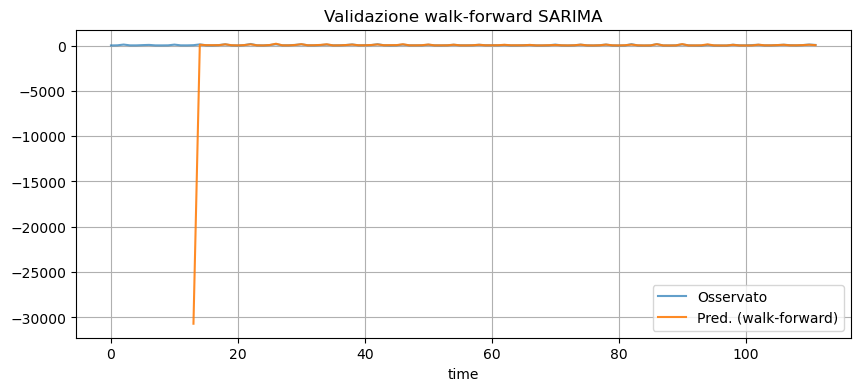

In [121]:
# Y: la tua serie trimestrale (pd.Series). Se hai un DataFrame a 1 colonna:
# Y = df.iloc[:, 0].astype(float).dropna()

# Parametri del modello (esempio: SARIMA(0,1,2)×(0,1,1)_4)
order = (0,1,2)
seasonal = (0,1,1,4)

# 1) Finestra espandente, orizzonte 1, passo 1
out_exp, metrics_exp = walk_forward_sarima(Y, order, seasonal, h=1, step=1, train_window=None)
print("Expanding window metrics:", metrics_exp)

# 2) Finestra scorrevole di 60 trimestri (~15 anni)
out_sl, metrics_sl = walk_forward_sarima(Y, order, seasonal, h=1, step=1, train_window=60)
print("Sliding window metrics:", metrics_sl)

# (opzionale) grafico delle previsioni vs realtà
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
Y.plot(label="Osservato", alpha=0.7)
out_exp["y_pred"].plot(label="Pred. (walk-forward)", alpha=0.9)
plt.title("Validazione walk-forward SARIMA")
plt.legend(); plt.grid(True); plt.show()


In [122]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ---------- metriche ----------
def mae(y_true, y_pred): 
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); 
    return np.mean(np.abs(y_true-y_pred))

def rmse(y_true, y_pred): 
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); 
    return np.sqrt(np.mean((y_true-y_pred)**2))

def smape(y_true, y_pred, eps=1e-8):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred)
    den = np.abs(y_true)+np.abs(y_pred)
    den = np.where(den<eps, eps, den)
    return 100*np.mean(2*np.abs(y_pred-y_true)/den)

# ---------- util: indice trimestrale ----------
def ensure_quarterly_index(y, start_period="1997Q1"):
    y = pd.Series(y).astype(float).dropna()
    if isinstance(y.index, (pd.PeriodIndex, pd.DatetimeIndex)) and getattr(y.index, "freqstr", None):
        return y
    y.index = pd.period_range(start=start_period, periods=len(y), freq="Q")
    return y

# ---------- rolling origin (sliding/expanding) con H orizzonti ----------
def rolling_origin_forecast(
    y, order, seasonal_order, 
    H=4,                   # orizzonte massimo (es. fino a 1 anno avanti)
    step=1,                # sposta l’origine di 'step' periodi
    train_window=None,     # None = expanding; int = sliding window fissa
    start_period="1997Q1",
    trend='n',
    enforce_stationarity=False,
    enforce_invertibility=False,
    verbose=False
):
    """
    Restituisce un DataFrame 'panel' con tutte le previsioni ordinate per origine e orizzonte,
    più un riassunto con metriche per h = 1..H.
    """
    y = ensure_quarterly_index(y, start_period=start_period)
    n = len(y)
    s = seasonal_order[3]

    # euristica per una finestra minima ragionevole
    p,d,q = order
    P,D,Q,_ = seasonal_order
    min_needed = max(8*s, 2*(p+q) + 2*s*(P+Q) + d + D*s + 16)

    if train_window is not None and train_window < min_needed:
        train_window = min_needed
        if verbose:
            print(f"train_window portata a {min_needed} per stabilità.")

    # prima origine (t) tale che abbiamo abbastanza train e spazio per H passi
    t0 = train_window if train_window is not None else min_needed
    results_rows = []

    t = t0
    while t + 1 <= n:  # almeno h=1
        # finestra di train
        if train_window is None:
            y_train = y.iloc[:t]               # expanding
        else:
            y_train = y.iloc[max(0, t-train_window):t]  # sliding

        # fit robusto
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = sm.tsa.SARIMAX(
                    y_train, order=order, seasonal_order=seasonal_order,
                    trend=trend,
                    enforce_stationarity=enforce_stationarity,
                    enforce_invertibility=enforce_invertibility
                )
                res = model.fit(disp=False, maxiter=200)
        except Exception as e1:
            try:
                res = model.fit(method='powell', disp=False, maxiter=200)
            except Exception as e2:
                if verbose:
                    print(f"[origin={y.index[t-1]}] fit fallito: {e2}")
                # registra NaN fino a H o fino a fine serie
                max_h_here = min(H, n - t)
                for h in range(1, max_h_here+1):
                    results_rows.append({
                        "origin": y.index[t-1],
                        "h": h,
                        "y_true": y.iloc[t+h-1],
                        "y_pred": np.nan
                    })
                t += step
                continue

        # quanti passi posso prevedere da questa origine
        max_h_here = min(H, n - t)
        if max_h_here <= 0:
            break

        fc = res.get_forecast(steps=max_h_here).predicted_mean

        for h in range(1, max_h_here+1):
            results_rows.append({
                "origin": y.index[t-1],
                "h": h,
                "y_true": y.iloc[t+h-1],
                "y_pred": fc.iloc[h-1]
            })

        t += step

    panel = pd.DataFrame(results_rows)
    # metriche per orizzonte
    summary = (
        panel.groupby("h")
        .apply(lambda g: pd.Series({
            "MAE": mae(g["y_true"], g["y_pred"]),
            "RMSE": rmse(g["y_true"], g["y_pred"]),
            "sMAPE%": smape(g["y_true"], g["y_pred"])
        }))
        .reset_index()
        .sort_values("h")
    )
    return panel, summary


In [123]:
# Se hai un DataFrame a 1 colonna:
# Y = df.iloc[:,0].astype(float).dropna()
# Altrimenti se è già Series:
# Y = df.astype(float).dropna()

order = (0,1,1)
seasonal = (0,1,1,4)

panel, summary = rolling_origin_forecast(
    Y, order, seasonal,
    H=8,                # orizzonti 1..8 trimestri
    step=1,             # origine che scorre di 1 trimestre
    train_window=80,    # sliding window (≈ 20 anni). Metti None per expanding.
    start_period="1997Q1",
    trend='n',
    verbose=False
)

print("Metriche per orizzonte (h):")
print(summary)


Metriche per orizzonte (h):
   h        MAE       RMSE     sMAPE%
0  1  13.031470  19.187328  42.814622
1  2  13.040599  19.411116  41.406726
2  3  12.670553  19.176192  38.754131
3  4  11.112554  17.335643  36.814751
4  5  18.833971  26.904157  57.256654
5  6  19.558556  27.515054  58.175587
6  7  19.600702  27.593307  58.531439
7  8  18.306286  26.129677  59.054616


/tmp/ipykernel_21766/1092137987.py:121: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


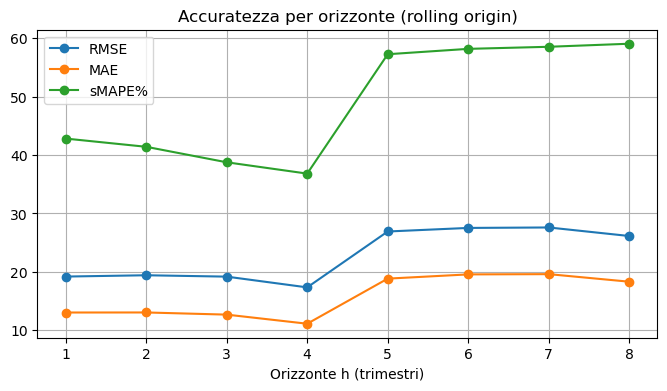

In [124]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(summary["h"], summary["RMSE"], marker="o", label="RMSE")
plt.plot(summary["h"], summary["MAE"], marker="o", label="MAE")
plt.plot(summary["h"], summary["sMAPE%"], marker="o", label="sMAPE%")
plt.xlabel("Orizzonte h (trimestri)")
plt.title("Accuratezza per orizzonte (rolling origin)")
plt.legend(); plt.grid(True); plt.show()


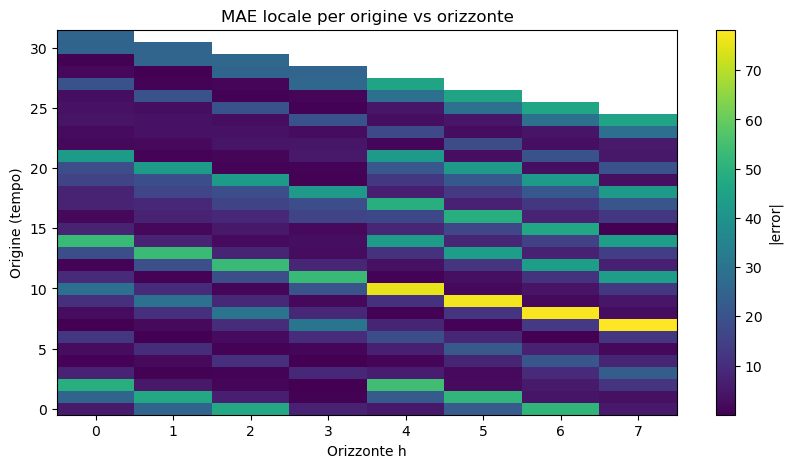

In [126]:
panel["abs_error"] = (panel["y_true"] - panel["y_pred"]).abs()

pivot_err = panel.pivot(index="origin", columns="h", values="abs_error")

plt.figure(figsize=(10,5))
plt.imshow(pivot_err, aspect="auto", cmap="viridis", origin="lower")
plt.title("MAE locale per origine vs orizzonte")
plt.xlabel("Orizzonte h")
plt.ylabel("Origine (tempo)")
plt.colorbar(label="|error|")
plt.show()




---

# Sezione aggiunta: Previsioni classiche & LSTM (template integrato)
Questa sezione è stata integrata automaticamente. Personalizza i **Parametri** e segui il flusso del template.



# Template: Previsioni tradizionali e LSTM per serie temporali

> **Istruzioni**
> - Sostituisci i percorsi ai file e i nomi delle colonne nella sezione **Parametri**.
> - Esegui le celle nell'ordine: Import → Parametri → Caricamento dati → Sezione che ti interessa (Classico o LSTM).
> - Il template include sia regressione sia classificazione a seconda della metrica scelta.


In [ ]:

# ==== Import ====
import numpy as np
import pandas as pd
from pathlib import Path

# Visualizzazione
import matplotlib.pyplot as plt

# Modeli classici
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, f1_score, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# LSTM
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)


## Parametri

In [ ]:

# ==== Parametri da personalizzare ====
# Percorso al dataset
DATA_PATH = Path('/mnt/data/tuo_dataset.csv')  # <-- Cambia con il tuo file

# Nome della colonna bersaglio (target)
TARGET_COL = 'y'  # <-- Cambia con la tua variabile dipendente

# Colonne da usare come feature (se None, usa tutte tranne il target)
FEATURE_COLS = None  # per selezionare automaticamente tutte tranne TARGET_COL

# Se è una SERIE TEMPORALE: indicare la colonna data/time (opzionale ma consigliato)
DATETIME_COL = None  # es. 'timestamp'  (deve essere parseable come datetime)

# Tipo problema: 'reg' per regressione continua, 'clf' per classificazione
PROBLEM_TYPE = 'reg'

# Per LSTM (finestra temporale)
WINDOW_SIZE = 24      # numero di step passati da usare
HORIZON = 1           # quanti step in avanti prevedere
TEST_SIZE = 0.2       # proporzione del dataset per test
VAL_SIZE = 0.1        # proporzione all'interno del train per validazione
RANDOM_STATE = 42
BATCH_SIZE = 64
EPOCHS = 30


## Caricamento dati

In [ ]:

# ==== Caricamento ====
assert DATA_PATH.exists(), f"File non trovato: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)

if DATETIME_COL is not None and DATETIME_COL in df.columns:
    df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors='coerce')
    df = df.sort_values(DATETIME_COL).reset_index(drop=True)

# Selezione feature
if FEATURE_COLS is None:
    FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]

print("Dimensioni dataset:", df.shape)
print("Target:", TARGET_COL)
print("Feature:", FEATURE_COLS[:10], "... (tot:", len(FEATURE_COLS), ")")
df.head()


## Parte A — Modelli classici (scikit-learn)

In [ ]:

# ==== Split train/test ====
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# Se è serie temporale e vuoi evitare leakage, usa split temporale; altrimenti train_test_split
if DATETIME_COL is not None:
    # Split temporale semplice
    n = len(df)
    n_test = int(TEST_SIZE * n)
    X_train, y_train = X[:-n_test], y[:-n_test]
    X_test, y_test = X[-n_test:], y[-n_test:]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True)

# Scaling (facoltativo ma consigliato per modelli lineari/logistici)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

if PROBLEM_TYPE == 'reg':
    # Regressione: LinearRegression + RandomForestRegressor
    models = {
        'LinearRegression': LinearRegression(),
        'RandomForestRegressor': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
    }
else:
    # Classificazione: LogisticRegression + RandomForestClassifier
    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'RandomForestClassifier': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300)
    }

results = {}
for name, model in models.items():
    if 'Forest' in name:
        # gli alberi non richiedono scaling, ma usiamo X_train (non scalato) per coerenza
        model.fit(X_train, y_train) if PROBLEM_TYPE=='reg' else model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        # modelli lineari/logistici beneficiano dello scaling
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

    if PROBLEM_TYPE == 'reg':
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    else:
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        results[name] = {'Accuracy': acc, 'F1_weighted': f1}

pd.DataFrame(results).T


In [ ]:

# ==== Grafico (solo per regressione) ====
if PROBLEM_TYPE == 'reg':
    # usa il miglior modello in base a RMSE
    res_df = pd.DataFrame(results).T
    best_name = res_df['RMSE'].idxmin()
    best_model = LinearRegression() if best_name=='LinearRegression' else RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
    if best_name=='LinearRegression':
        best_model.fit(scaler.fit_transform(X_train), y_train)
        y_hat = best_model.predict(scaler.transform(X_test))
    else:
        best_model.fit(X_train, y_train)
        y_hat = best_model.predict(X_test)

    plt.figure()
    plt.plot(y_test, label='Reale')
    plt.plot(y_hat, label='Predetto')
    plt.title(f'Confronto Reale vs Predetto — {best_name}')
    plt.legend()
    plt.show()
else:
    # Report di classificazione per il modello scelto (RandomForest)
    clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(classification_report(y_test, y_pred))


## Parte B — LSTM per serie temporali

In [ ]:

# ==== Preparazione dati per LSTM (finestratura) ====
assert DATETIME_COL is not None, "Per LSTM di serie temporali, specifica DATETIME_COL nelle impostazioni."

# Selezioniamo solo feature numeriche per semplicità
num_df = df.select_dtypes(include=[np.number]).copy()
assert TARGET_COL in num_df.columns, "Il target deve essere numerico o convertibile."
num_features = [c for c in num_df.columns if c != TARGET_COL]

# Scaling su TUTTE le feature + target (per inverse_transform sul target poi)
scaler_all = StandardScaler()
scaled = scaler_all.fit_transform(num_df[num_features + [TARGET_COL]])
scaled_df = pd.DataFrame(scaled, columns=num_features + [TARGET_COL])

def make_windows(data_array, target_index, window_size=24, horizon=1):
    Xs, ys = [], []
    for i in range(len(data_array) - window_size - horizon + 1):
        window = data_array[i:i+window_size, :]
        target_val = data_array[i+window_size+horizon-1, target_index]
        Xs.append(window)
        ys.append(target_val)
    return np.array(Xs), np.array(ys)

data_array = scaled_df.values
target_idx = scaled_df.columns.get_loc(TARGET_COL)
X_seq, y_seq = make_windows(data_array, target_idx, WINDOW_SIZE, HORIZON)

n_total = len(X_seq)
n_test = int(TEST_SIZE * n_total)
n_val = int(VAL_SIZE * (n_total - n_test))

X_train, y_train = X_seq[:-(n_test + n_val)], y_seq[:-(n_test + n_val)]
X_val, y_val = X_seq[-(n_test + n_val):-n_test], y_seq[-(n_test + n_val):-n_test]
X_test, y_test = X_seq[-n_test:], y_seq[-n_test:]

X_train.shape, X_val.shape, X_test.shape


In [ ]:

# ==== Modello LSTM ====
def build_lstm(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
    return model

model = build_lstm(X_train.shape[1:])
model.summary()


In [ ]:

# ==== Training ====
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callbacks
)


In [ ]:

# ==== Valutazione ====
pred_test = model.predict(X_test).squeeze()

# Inverse scaling per riportare il target alla scala originale
# Costruiamo un array di placeholder per utilizzare inverse_transform sul target
def inverse_target(scaled_target_vals, scaler, target_col_name, feature_names):
    # scaler è stato fit su [num_features + target]
    # Ricostruiamo array vuoto e inseriamo i valori del target nella colonna giusta
    idx = feature_names + [target_col_name]
    target_index = len(idx) - 1
    dummy = np.zeros((len(scaled_target_vals), len(idx)))
    dummy[:, target_index] = scaled_target_vals
    inv = scaler.inverse_transform(dummy)
    return inv[:, target_index]

y_test_inv = inverse_target(y_test, scaler_all, TARGET_COL, num_features)
pred_test_inv = inverse_target(pred_test, scaler_all, TARGET_COL, num_features)

rmse = mean_squared_error(y_test_inv, pred_test_inv, squared=False)
mae = mean_absolute_error(y_test_inv, pred_test_inv)
print(f"RMSE (test): {rmse:.4f} | MAE (test): {mae:.4f}")


In [ ]:

# ==== Grafico pred vs reale ====
plt.figure()
plt.plot(y_test_inv, label='Reale')
plt.plot(pred_test_inv, label='Predetto (LSTM)')
plt.title('Confronto Reale vs Predetto — LSTM')
plt.legend()
plt.show()



### Note & consigli
- **Evitare leakage**: per serie temporali, non mischiare futuro con passato nello split.
- **Feature engineering**: valuta lag, rolling mean/std, differenze, dummy per stagionalità/ora.
- **Scelta finestra (`WINDOW_SIZE`)**: prova più valori (es. 24, 48, 168) in base alla stagionalità.
- **Classificazione con LSTM**: se il target è categorico, converti in interi o one-hot e usa `loss='sparse_categorical_crossentropy'` o `categorical_crossentropy` con `Dense(n_classi, activation='softmax')`.
- **Multi-step forecast**: aumenta `HORIZON` o usa strategie ricorsive.
- **Salvataggio modello**: `model.save('/mnt/data/lstm_model.keras')`.
